In [2]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from data_loader import *

Function for recovering and computing concrete privacy levels of quantum and quantum-inspired recommendation algorithm

In [3]:
def eps_delta(μ, m, n, k, ε_approx, Trowmin, C_eps=2, C_delta=2):
    eps = C_eps * np.sqrt(μ*k / n)

    fac1 = 1/min(m,n)
    fac2 = 1/np.sqrt(m*n)
    delta_nom = (μ*k)**2 * ((fac1 + fac2)**2 - fac1**2)
    delta_den = Trowmin*ε_approx
    delta = delta_nom/delta_den
    delta = C_delta * delta
    return eps, delta

Parameter estimate of hyperthetical datasets:

$m = 2n$

$k = \log^2n = O(\log(mn))$

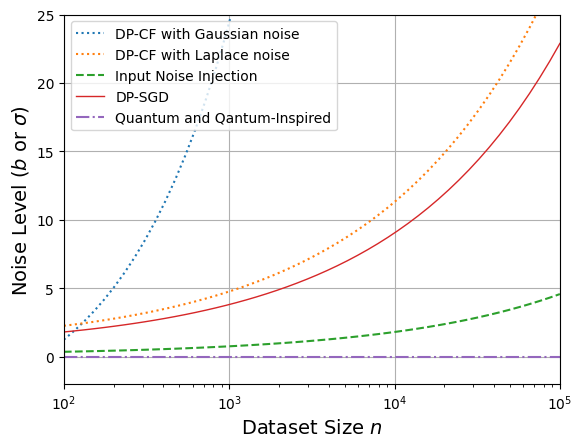

In [12]:
N = np.geomspace(100, 100000)
Eps   = np.array([eps_delta(9, 2*n, n, np.log(n)**2, 0.5, 20, 2, 2)[0] for n in N])
Delta = np.array([eps_delta(9, 2*n, n, np.log(n)**2, 0.5, 20, 2, 2)[1] for n in N])
B_DPSGD = 5/Eps
B_IPSGD = 1/Eps
S_DPCF  = 2.5*np.log(2/Delta)/Eps * (1+2*np.sqrt(2))
S_DPCF  = np.clip(S_DPCF, 0, 1000000)
B_DPCF  = 25/4/Eps
Q       = 0*Eps
plt.plot(N, S_DPCF,  linestyle=':',  label='DP-CF with Gaussian noise')
plt.plot(N, B_DPCF,  linestyle=':',  label='DP-CF with Laplace noise')
plt.plot(N, B_IPSGD, linestyle='--', label='Input Noise Injection')
plt.plot(N, B_DPSGD, linestyle='-',  label='DP-SGD', linewidth=1)
plt.plot(N, Q,       linestyle='-.', label='Quantum and Qantum-Inspired')
plt.xscale('log')
plt.grid(); plt.legend()
plt.xlabel(r'Dataset Size $n$', fontsize=14)
plt.ylabel(r'Noise Level ($b$ or $\sigma$)', fontsize=14)
plt.ylim(-2, 25)
plt.xlim(100, 100000)

plt.savefig('equal_eps_noise_level_curve.jpg', dpi=400, bbox_inches='tight')